# Libraries 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.utils.fixes import parse_version, sp_version
import seaborn as sns

# This is line is to avoid incompatibility if older SciPy version.
# You should use `solver="highs"` with recent version of SciPy.
solver = "highs" if sp_version >= parse_version("1.6.0") else "interior-point"
pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', None)

# **Function used for correction of vertical speed**

In [11]:
def vertical_speed_over_time(all_tracks, track_nb_thr):

    '''
    Fitting a polynomial regression on the vertical
    speed distribution over time for each sequence
    and then subtracting the predicted values to the
    raw vertical speed to get closer to the real sinking
    speed by removing the local background noise.
    The function also returns the r-squared value of the
    regression to estimate its quality and other morphological
    features of the tracks
    '''

    # Display a plot with the vertical speed of all the tracks detected in a sequence over time
    all_tracks['datetime'] = pd.to_datetime(all_tracks['datetime'])
    time_diff_seconds = (all_tracks['datetime'] - all_tracks['datetime'].iloc[0]).dt.total_seconds()
    all_tracks['time_seconds'] = time_diff_seconds

    sequence = all_tracks['sequence'].unique()[0]

    track_ids = []
    mean_datetimes = []
    mean_vertical_speeds = []
    mean_greys = []
    mean_size = []

    # Loop over unique track_ids and plot each group with a unique color
    for track_id, group in all_tracks.groupby('track_id'):
        mean_datetime = group['time_seconds'].mean()
        mean_vertical_speed = group['vertical_speed'].mean()
        meangrey = group['meangrey'].mean()
        size = group['esd_um'].mean()

        track_ids.append(track_id)
        mean_datetimes.append(mean_datetime)
        mean_vertical_speeds.append(mean_vertical_speed)
        mean_greys.append(meangrey)
        mean_size.append(size)

    data = {
        'track_id': track_ids,
        'mean_datetime': mean_datetimes,
        'mean_vertical_speed': mean_vertical_speeds, 
        'sequence': sequence,
        'size_um': mean_size,
        'meangrey' : mean_greys
    }

    stacked_data = pd.DataFrame(data)

    # define the x and y variable 
    X = stacked_data['mean_datetime'].values.reshape(-1, 1)
    y = stacked_data['mean_vertical_speed']

    if len(y) >= track_nb_thr:
        # Create figure for the sequence

        # Uncomment all the lines below to create Figure S5a analogues for each sequence

        #fig, ax = plt.subplots(figsize=(10, 10))

        # Polynomial regression
        polynomial_features = PolynomialFeatures(degree=2)
        X_poly = polynomial_features.fit_transform(X)

        poly_reg_model = LinearRegression()
        poly_reg_model.fit(X_poly, y)
        y_pred = poly_reg_model.predict(X_poly)

        r2 = r2_score(y, y_pred)

        predictions = pd.DataFrame({
            'pred_poly': y_pred,
            'r2': [r2] * len(y)
        })


        #plt.plot(X, predictions['pred_poly'], linewidth=3, color = 'red')

        #sc = plt.scatter(stacked_data['mean_datetime'], stacked_data['mean_vertical_speed'], c = stacked_data['meangrey'], s = stacked_data['size_um'], cmap = 'viridis_r')

        # Add  colorbar
        #cbar = plt.colorbar(sc)
        #cbar.set_label('Mean grey', size=15)

        #ax.axhline(y = 0, color = 'r', linestyle = '--')
        #ax.invert_yaxis()
        #ax.set_xlabel('Time (seconds)')
        #ax.set_ylabel('Vertical Speed')


        # Add other information
        predictions['sequence'] = sequence
        predictions['track_id'] = track_ids
        predictions['vertical_speed'] = mean_vertical_speeds
        predictions['size_um'] = mean_size
        predictions['meangrey'] = mean_greys
        predictions['time'] = mean_datetimes

        # Estimate the quality of the regression
        n = len(y_pred) # number of data points

        predictions['error'] = predictions['vertical_speed'] - predictions['pred_poly']
        predictions['mse'] = mean_squared_error(y, y_pred)
        predictions['rmse'] = np.sqrt(predictions['mse']) # Root Mean Square Error

        #ax.set_title(f"Vertical speed over the sequence {sequence} ; n = {len(y)} ; r2 = {round(predictions['r2'][0], 2)}")

        #ax.grid(True)

        #ax.axis('tight')

        #plt.legend(*sc.legend_elements("sizes", num=6), title="ESD µm", bbox_to_anchor=(1.4, 1), labelspacing = 4, frameon=False, title_fontsize='large')

        #if r2 >= 0.5:
         #   print('R2 ok, saving figure', r2)
          #  filename = f"/home/aaccardo/these_alex/Analysis/APERO/TZEX/vlfr_test/Figures/poly_reg/{sequence}_reg.pdf"
           # plt.savefig(filename, dpi = 300)
        #plt.close()
        #plt.show()

        return predictions

    else:
        print('Not enough tracks in the sequence')
        predictions = pd.DataFrame(columns=['pred_poly', 'sequence', 'track_id', 'vertical_speed', 'size_um', 'meangrey', 'time', 'error', 'mse', 'rmse', 'r2'])
        return predictions

def make_asc_neg(data):
    if ('asc' in data['orientation'].values) and (data['vertical_speed'] >= 0).all():
        print('Making the ascending tracks negative...')
        asc = data[data['orientation'] == 'asc'].copy()  # Filter ascending tracks
        asc['vertical_speed'] = asc['vertical_speed'] * -1  # Invert vertical speeds
        desc = data[data['orientation'] == 'desc'].copy()  # Filter descending tracks
        mix = data[data['orientation'] == 'mix'].copy()  # Filter mixed tracks
        data = pd.concat([asc, desc, mix], axis=0, ignore_index=True)  # Concatenate back
        print(data['vertical_speed'].describe())  # Display description of vertical speeds
    else:
        print('No action needed.')

    return data

# Plotting function
def hist_corrected(track_particle):

    print('n = ', len(track_particle['track_id'].unique()))
    n = len(track_particle['track_id'].unique())
    asc = track_particle[track_particle['vertical_speed'] < 0]
    n_asc = len(asc['track_id'].unique())
    print('n asc = ', n_asc)
    desc = track_particle[track_particle['vertical_speed'] > 0]
    n_desc = len(desc['track_id'].unique())
    print('n desc = ', n_desc)
    '''
    asc = track_particle[track_particle['corrected_orientation'] == 'asc']
    print('n asc = ', len(asc['track_id'].unique()))
    desc = track_particle[track_particle['corrected_orientation'] == 'desc']
    print('n desc = ', len(desc['track_id'].unique()))
    '''
    fig, ax = plt.subplots(figsize=(10, 10))

    # median
    med_speed = track_particle['vertical_speed'].median()
    print("med =", med_speed)    

    sns.histplot(track_particle['vertical_speed'], bins = 200, kde=False, color="#10698D", ax=ax, alpha = 1)

    ax.axvline(med_speed, color='#FFC000', linestyle='dashed', linewidth=3, label=f'median',  alpha = 1)  


    ax.tick_params(axis='both', labelsize=15)
    ax.set_xlabel("Raw vertical speed ($m$.$d^{-1}$)", size = 15)
    ax.set_ylabel("Frequency", size = 15)
    ax.set_title(f'Raw vertical speed distribution', size = 15)
    ax.legend()
    #ax.text(0.9, 0.475, f'Median = {med_speed:.1f}', transform=ax.transAxes, fontsize=12, ha='center')
    #ax.text(0.9, 0.45, f'n = {n}', transform=ax.transAxes, fontsize=12, ha='center')
    #ax.text(0.9, 0.425, f'n asc = {n_asc}', transform=ax.transAxes, fontsize=12, ha='center')
    #ax.text(0.9, 0.4, f'n desc = {n_desc}', transform=ax.transAxes, fontsize=12, ha='center')
    #ax.axis('tight')
    ax.set_xlim(-1000, 1000)
    #plt.savefig("/home/aaccardo/these_alex/Analysis/APERO/TZEX/all_cycle_analysis/Figures/Raw_vertical_speed_all_APERO.pdf", dpi=300)
    #plt.close()


    plt.show()

# Import dataset with raw tracks (Med Sea)

In [6]:
data = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Vertical_speeds/VLFR_tracks_all.tsv', delimiter='\t')
data['datetime'] = data['datetime'].str.replace('.000', '')
data['datetime'] = data['datetime'].str.replace('.500', '')
data['datetime'] = pd.to_datetime(data['datetime'])
# if all the tracks are positives then make the ascending ones negatives
vlfr = make_asc_neg(data)
vlfr.head(5)

Making the ascending tracks negative...
count    718261.000000
mean         -2.806639
std          89.876351
min       -1278.526993
25%         -60.745834
50%          -6.711939
75%          54.950967
max        1581.816540
Name: vertical_speed, dtype: float64


,track_id,track_length,speed,angle,vertical_speed,orientation,sequence,part_id,n_img,img_name,datetime,coord_x,coord_y,area_px,esd_px,perim_px,area_um,esd_um,major_px,minor_px,orientation_particle,perimmajor,meangrey,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,filename,PC1,PC2,PC3,PC4,PC5,roll,potential_match,euclidean_distance,sequence_ini,date_ini
0,vlfr_20230418-062656-1-5357,4,197.894304,63.618946,-176.938222,asc,20230418-062321,5357,210,20230418-062656-1,2023-04-18 06:26:56,943.625000,1751.250000,16.0,4.513517,12.242641,53654.745140,261.372040,4.837184,4.165532,0.259573,2.530944,86.750000,46.179676,53.233056,1388,94.0,29,191,162,17.0,0.508354,0.800000,0.941176,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,3.507195,-1.438248,-0.933943,-0.949182,-0.286079,0,False,0.000000,20230418-062321,2023-04-18 06:26:56
1,vlfr_20230418-062656-1-5357,4,197.894304,63.618946,-176.938222,asc,20230418-062321,5394,211,20230418-062657-1,2023-04-18 06:26:57,959.000000,1722.909091,11.0,3.742410,9.035534,35054.996360,211.266201,4.596473,3.047237,-1.313993,1.965754,84.090909,43.654542,51.913509,925,79.0,28,160,132,12.0,0.748663,0.733333,0.916667,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,2.222318,-0.423289,0.761471,-1.031041,1.316935,0,False,18605.636217,20230418-062321,2023-04-18 06:26:56
2,vlfr_20230418-062656-1-5357,4,197.894304,63.618946,-176.938222,asc,20230418-062321,5423,212,20230418-062658-1,2023-04-18 06:26:58,973.769231,1696.615385,13.0,4.068429,10.828427,42380.637407,232.294433,4.296689,3.904178,-1.030377,2.520179,75.615385,46.921438,62.052766,983,65.0,24,156,132,14.0,0.417563,0.812500,0.928571,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,2.911915,-1.825461,0.707642,-0.946633,0.007732,0,False,7325.929894,20230418-062321,2023-04-18 06:26:56
3,vlfr_20230418-062656-1-5357,4,197.894304,63.618946,-176.938222,asc,20230418-062321,5446,213,20230418-062659-1,2023-04-18 06:26:59,985.312500,1667.062500,16.0,4.513517,12.242641,53654.745140,261.372040,5.326819,3.741657,-0.321751,2.298302,81.937500,43.804207,53.460513,1311,73.5,25,140,115,17.0,0.711764,0.800000,0.941176,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,3.203119,-0.858674,-0.366529,-0.572890,0.379601,0,False,11278.949325,20230418-062321,2023-04-18 06:26:56
4,vlfr_20230418-062742-1-6805,4,68.031529,106.644050,-64.448264,asc,20230418-062321,6805,255,20230418-062742-1,2023-04-18 06:27:42,719.500000,1428.500000,8.0,3.191538,8.000000,24413.950587,176.308841,4.472136,2.000000,1.570796,1.788854,58.375000,28.066606,48.079839,467,48.0,26,99,73,8.0,0.894427,1.000000,1.000000,/home/aaccardo/these_alex/Analysis/APERO/TZEX/...,0.426899,-0.053132,-2.063025,1.187520,-0.598932,0,False,0.000000,20230418-062321,2023-04-18 06:27:42


In [7]:
summary_vlfr = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Vertical_speeds/VLFR_tracks_summary.tsv', delimiter='\t')
summary_vlfr = make_asc_neg(summary_vlfr)
print('vlfr: ', len(summary_vlfr))

summary_vlfr.head(5)

Making the ascending tracks negative...
count    59766.000000
mean        -2.367830
std         87.099368
min      -1278.526993
25%        -57.378304
50%         -6.951244
75%         51.229687
max       1581.816540
Name: vertical_speed, dtype: float64
vlfr:  59766


,Cycle,Depth,seq,track_id,length,img_ini,img_fin,datetime_ini,datetime_fin,angle_mean,angle_std,mean_orientation_particle,speed,vertical_speed,vx,orientation,sinusoity_index,step_length_mean,step_length_std,longest_distance,rmsd,roll_correction,vig_name,area_px,esd_px,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,meangrey,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity
0,vlfr,NaN,20230418-062321,vlfr_20230418-062656-1-5357,4,20230418-062656-1,20230418-062659-1,2023-04-18 06:26:56,2023-04-18 06:26:59,63.618946,3.584091,35.073495,197.894304,-176.938222,87.643800,asc,1.524712,2290.443331,64.731540,2.769610,17.687102,0,vlfr_20230418-062656-1-5357.png,14.5,4.290973,11.535534,48017.691274,246.833236,4.716829,3.822918,2.409241,83.014205,44.991942,53.346784,1147.0,76.25,26.5,158.0,132.0,15.5,0.610059,0.800000,0.934874
1,vlfr,NaN,20230418-062321,vlfr_20230418-062742-1-6805,4,20230418-062742-1,20230418-062746-1,2023-04-18 06:27:42,2023-04-18 06:27:46,106.644050,9.496481,350.086477,68.031529,-64.448264,14.191200,asc,2.116017,1049.869276,492.453895,2.978188,15.027945,0,vlfr_20230418-062742-1-6805.png,8.5,3.288338,8.121320,26161.573329,182.408190,4.109592,2.598999,1.955050,67.354167,29.390712,44.793174,574.0,67.50,27.5,112.5,85.0,9.0,0.753499,0.791667,1.000000
2,vlfr,NaN,20230418-062321,vlfr_20230418-062909-1-9191,4,20230418-062909-1,20230418-062912-1,2023-04-18 06:29:09,2023-04-18 06:29:12,44.135545,10.878138,54.309839,104.980590,-71.961338,72.182400,asc,1.403718,1215.053127,327.582097,2.400419,4.436789,0,vlfr_20230418-062909-1-9191.png,8.0,3.191538,7.621320,24413.950587,176.308841,3.674927,2.767028,2.130773,86.937500,39.700035,53.224635,686.5,80.25,26.5,157.0,119.5,8.5,0.653480,0.763889,1.000000
3,vlfr,NaN,20230418-062321,vlfr_20230418-062951-1-10261,4,20230418-062951-1,20230418-062954-1,2023-04-18 06:29:51,2023-04-18 06:29:54,15.650197,3.697595,51.260735,279.204711,-75.166490,268.836891,asc,1.412147,3231.536011,386.375762,0.000000,27.667286,0,vlfr_20230418-062951-1-10261.png,28.0,5.967007,19.399495,101360.935107,358.948712,8.412561,4.501207,2.165098,59.240476,26.785175,45.628847,1731.0,54.75,24.5,135.5,110.5,32.5,0.827605,0.556746,0.864943
4,vlfr,NaN,20230418-070321,vlfr_20230418-070348-1-188,4,20230418-070348-1,20230418-070351-1,2023-04-18 07:03:48.000,2023-04-18 07:03:51,58.007032,22.829726,312.783363,163.723661,-128.513794,73.240338,asc,1.422583,1894.949780,258.185541,11.846122,10.587192,0,vlfr_20230418-070348-1-188.png,14.0,4.219311,11.449747,46121.193096,242.129309,5.416456,4.055434,2.044046,61.431250,28.003252,46.604834,838.0,61.25,23.5,123.5,99.5,17.0,0.664016,0.468333,0.777090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59761,vlfr,NaN,20230502-063319,vlfr_20230502-063820-1-8331,5,20230502-063820-1,20230502-063824-1,2023-05-02 06:38:20,2023-05-02 06:38:24,221.188688,26.340969,340.528779,5.965620,3.492518,3.942000,mix,1.399091,69.046533,20.562105,0.668965,0.583671,0,vlfr_20230502-063820-1-8331.png,4.0,2.256758,4.000000,11108.821442,118.929352,2.309401,1.732051,1.633883,53.333333,22.884219,37.448311,176.0,40.50,29.0,91.0,55.0,4.0,0.790569,0.750000,1.000000
59762,vlfr,NaN,20230502-063319,vlfr_20230502-063823-1-8419,7,20230502-063823-1,20230502-063830-1,2023-05-02 06:38:23,2023-05-02 06:38:30,174.710361,12.531441,333.241953,9.904872,0.894945,9.663531,mix,1.180322,133.746337,39.059081,0.387048,1.803948,0,vlfr_20230502-063823-1-8419.png,5.0,2.523133,4.621320,14313.892819,135.000053,3.677089,1.732051,1.606081,51.428571,18.278659,39.872773,249.0,39.00,25.0,77.0,44.0,6.0,0.816497,0.666667,0.833333
59763,vlfr,NaN,20230502-063319,vlfr_20230502-063827-1-8529,15,20230502-063827-1,20230502-063843-1,2023-05-02 06:38:27,2023-05-02 06:38:43,187.886528,11.433689,8.754106,16.962984,2.283372,16.457850,mix,1.085854,224.378092,58.407138,1.691333,3.040555,0,vlfr_2

In [6]:
print('nb sequences: ', len(summary_vlfr['seq'].unique()))

nb sequences:  342


# Look at raw vertical distribution

n =  59766
n asc =  31288
n desc =  28478
med = -6.951244279977269


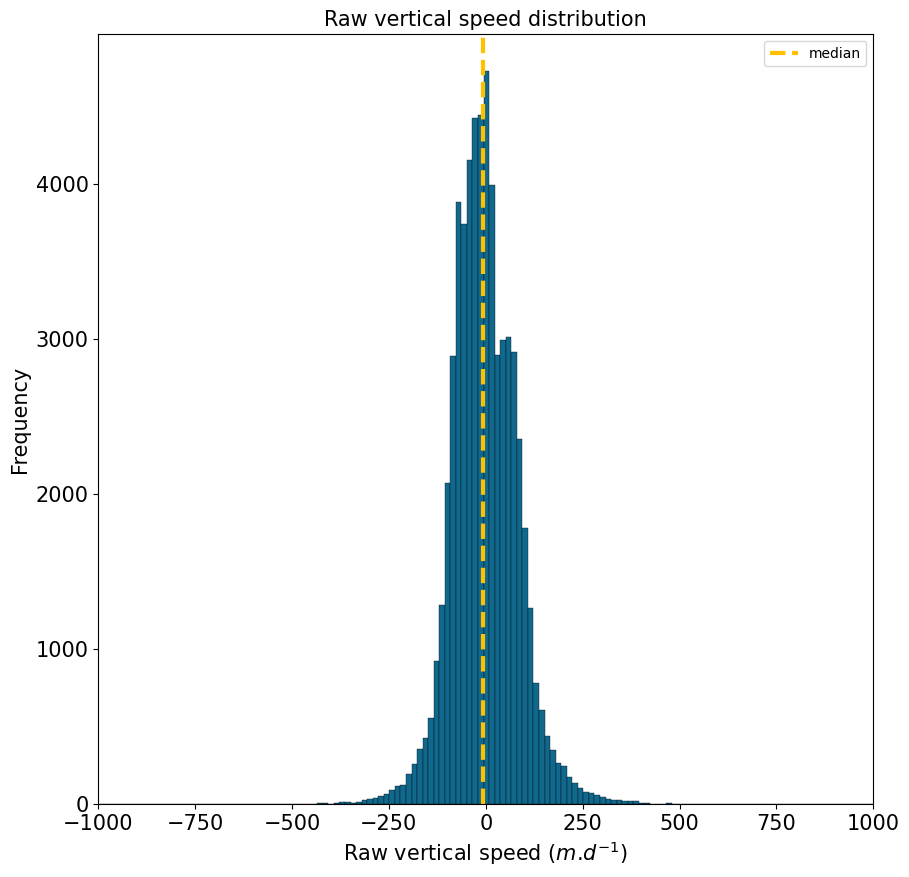

In [7]:
hist_corrected(summary_vlfr)

In [10]:
data = vlfr.sort_values(by='sequence', ascending=True)

In [11]:
sequences = data['sequence'].unique()
sequences.head(3)

array(['20230418-062321', '20230418-070321', '20230418-074321',
       '20230418-082321', '20230418-090321', '20230418-114321',
       '20230418-122321', '20230418-130321', '20230418-134321',
       '20230418-142321', '20230418-150321', '20230418-154321',
       '20230418-162321', '20230418-170321', '20230418-174321',
       '20230418-182321', '20230418-190321', '20230418-202321',
       '20230418-210321', '20230418-214321', '20230418-222321',
       '20230418-230321', '20230418-234321', '20230419-002321',
       '20230419-010321', '20230419-014321', '20230419-022321',
       '20230419-030321', '20230419-034321', '20230419-042321',
       '20230419-050321', '20230419-054321', '20230419-062321',
       '20230419-173817', '20230419-181817', '20230419-185817',
       '20230419-193817', '20230419-201817', '20230419-205817',
       '20230419-213817', '20230419-221817', '20230419-225817',
       '20230419-233817', '20230420-001817', '20230420-005817',
       '20230420-013817', '20230420-0218

# Correction procedure

In [13]:
all_prediction = pd.DataFrame()
sequence_count = 0
total_sequences = len(sequences)

# Iterate over sequences
for sequence in sequences:
    sequence_count += 1
    print(f'Processing sequence {sequence_count}/{total_sequences}: {sequence}')

    all_tracks = data[data['sequence'] == sequence]
    all_tracks = all_tracks.sort_values(by='datetime', ascending=True)
    #print(all_tracks)

    min_date = all_tracks['datetime'].min()
    #print(min_date)
    #print(max_date)
    max_date = all_tracks['datetime'].max()
    #float_speed_seq = float_speed[(float_speed['Date_time'] >= min_date) & (float_speed['Date_time'] <= max_date)]
    #print(float_speed_seq)

    # Use correction function
    predicted_data = vertical_speed_over_time(all_tracks=all_tracks,
                                              track_nb_thr=100)

    all_prediction = pd.concat([all_prediction, predicted_data])

all_prediction

Processing sequence 1/342: 20230418-062321
Not enough tracks in the sequence
Processing sequence 2/342: 20230418-070321
Not enough tracks in the sequence
Processing sequence 3/342: 20230418-074321
Not enough tracks in the sequence
Processing sequence 4/342: 20230418-082321
Not enough tracks in the sequence
Processing sequence 5/342: 20230418-090321


/tmp/ipykernel_1349704/1943091217.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_prediction = pd.concat([all_prediction, predicted_data])
/tmp/ipykernel_1349704/1943091217.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_prediction = pd.concat([all_prediction, predicted_data])
/tmp/ipykernel_1349704/1943091217.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA

Processing sequence 6/342: 20230418-114321
Not enough tracks in the sequence
Processing sequence 7/342: 20230418-122321
Not enough tracks in the sequence
Processing sequence 8/342: 20230418-130321
Not enough tracks in the sequence
Processing sequence 9/342: 20230418-134321
Not enough tracks in the sequence
Processing sequence 10/342: 20230418-142321


/tmp/ipykernel_1349704/1943091217.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_prediction = pd.concat([all_prediction, predicted_data])
/tmp/ipykernel_1349704/1943091217.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_prediction = pd.concat([all_prediction, predicted_data])


Processing sequence 11/342: 20230418-150321
Not enough tracks in the sequence
Processing sequence 12/342: 20230418-154321
Processing sequence 13/342: 20230418-162321
Processing sequence 14/342: 20230418-170321
Not enough tracks in the sequence
Processing sequence 15/342: 20230418-174321
Processing sequence 16/342: 20230418-182321
Not enough tracks in the sequence
Processing sequence 17/342: 20230418-190321


...

Not enough tracks in the sequence
Processing sequence 338/342: 20230502-051319
Processing sequence 339/342: 20230502-055319


/tmp/ipykernel_1349704/1943091217.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_prediction = pd.concat([all_prediction, predicted_data])


Processing sequence 340/342: 20230502-063319
Processing sequence 341/342: 20230502-071319
Processing sequence 342/342: 20230503-013458
Not enough tracks in the sequence


/tmp/ipykernel_1349704/1943091217.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_prediction = pd.concat([all_prediction, predicted_data])


,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2
0,22.056680,20230418-090321,vlfr_20230418-090344-1-26,-64.737437,126.431568,46.852778,2.500000,-86.794117,5268.166118,72.582134,0.079274
1,21.397995,20230418-090321,vlfr_20230418-090344-1-36,-49.388180,139.763790,80.666369,3.500000,-70.786176,5268.166118,72.582134,0.079274
2,20.741929,20230418-090321,vlfr_20230418-090344-1-39,32.370750,135.328178,80.086667,4.500000,11.628821,5268.166118,72.582134,0.079274
3,21.397995,20230418-090321,vlfr_20230418-090346-1-102,-14.380660,114.447158,75.541667,3.500000,-35.778656,5268.166118,72.582134,0.079274
4,21.397995,20230418-090321,vlfr_20230418-090346-1-114,64.117928,130.054785,65.973214,3.500000,42.719933,5268.166118,72.582134,0.079274
...,...,...,...,...,...,...,...,...,...,...,...
101,113.971458,20230502-071319,vlfr_20230502-072027-1-10709,122.401878,190.672116,80.178732,407.000000,8.430420,1698.671603,41.214944,0.042734
102,114.222835,20230502-071319,vlfr_20230502-072028-1-10747,93.822695,165.171059,61.391111,406.000000,-20.400140,1698.671603,41.214944,0.042734
103,112.439408,20230502-071319,vlfr_20230502-072030-1-10783,99.052315,247.074970,85.325737,413.000000,-13.387093,1698.671603,41.214944,0.042734
104,113.040052,20230502-071319,vlfr_20230502-072032-1-10829,83.924946,120.231854,64.263889,410.666667,-29.115106,1698.671603,41.214944,0.042734


In [14]:
# group the data_parking dataset by track id and compute the mean of all the other morpholigical features and merge them to the all_prediction one
df_morpho = data[['track_id', 'perim_px', 'area_um',
                  'esd_um', 'major_px', 'minor_px',
                  'perimmajor', 'stdgrey', 'cvgrey',
                  'intgrey', 'mediangrey', 'mingrey',
                  'maxgrey', 'rangegrey', 'area_convex',
                  'eccentricity', 'extent', 'solidity']]

df_morpho = df_morpho.groupby('track_id').mean().reset_index()

df_morpho.head(5)

,track_id,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity
0,vlfr_20230418-062656-1-5327,6.587006,21198.962096,160.686633,3.883844,2.491846,1.656920,20.985270,31.900505,461.600,63.700,34.600,94.80,60.200,8.20,0.753341,0.637500,0.849231
1,vlfr_20230418-062656-1-5357,11.087311,46186.281012,241.576178,4.764291,3.714651,2.328795,45.139966,55.164961,1151.750,77.875,26.500,161.75,135.250,15.00,0.596586,0.786458,0.931898
2,vlfr_20230418-062701-1-5489,5.455635,19012.718120,154.469562,3.844806,2.352898,1.443543,25.092446,40.237773,393.200,56.300,28.600,97.80,69.200,7.80,0.759480,0.647222,0.820635
3,vlfr_20230418-062742-1-6805,8.026650,27048.715058,185.314586,4.144269,2.547831,1.942876,28.505501,42.668731,588.750,64.000,26.750,112.00,85.250,9.00,0.771139,0.812500,0.972222
4,vlfr_20230418-062742-1-6806,8.742641,30643.606663,196.439196,3.692271,3.303317,2.364017,32.036520,46.532896,678.125,65.875,27.625,115.25,87.625,10.25,0.351141,0.723958,0.950893


In [15]:
# Merge with dataframe containing corrected vertical speed
all_prediction = pd.merge(all_prediction, df_morpho, on='track_id')

In [16]:
# Count number of tracks per sequence and add it as a column in the all_prediction dataframe
all_prediction['track_count'] = all_prediction.groupby('sequence')['track_id'].transform('nunique')
all_prediction.head(3)

,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count
0,22.056680,20230418-090321,vlfr_20230418-090344-1-26,-64.737437,126.431568,46.852778,2.500000,-86.794117,5268.166118,72.582134,0.079274,3.810660,12744.211723,126.431568,3.555859,1.735868,1.106255,19.196437,39.553131,216.500000,44.083333,26.000000,79.333333,53.333333,5.500000,0.828826,0.583333,0.835714,192
1,21.397995,20230418-090321,vlfr_20230418-090344-1-36,-49.388180,139.763790,80.666369,3.500000,-70.786176,5268.166118,72.582134,0.079274,5.543655,15601.461761,139.763790,2.984396,2.062483,1.860506,42.150258,53.508569,441.500000,70.375000,34.500000,149.000000,114.500000,5.375000,0.632108,0.798611,1.000000,192
2,20.741929,20230418-090321,vlfr_20230418-090344-1-39,32.370750,135.328178,80.086667,4.500000,11.628821,5268.166118,72.582134,0.079274,5.255635,14716.986296,135.328178,2.862515,1.966259,1.824330,31.865233,40.941456,401.900000,72.300000,44.000000,133.100000,89.100000,5.100000,0.657349,0.827778,1.000000,192
3,21.397995,20230418-090321,vlfr_20230418-090346-1-102,-14.380660,114.447158,75.541667,3.500000,-35.778656,5268.166118,72.582134,0.079274,3.853553,10334.600588,114.447158,2.077350,1.833333,1.869599,24.678013,33.353000,285.500000,79.375000,43.500000,104.000000,60.500000,3.750000,0.204124,0.937500,1.000000,192
4,21.397995,20230418-090321,vlfr_20230418-090346-1-114,64.117928,130.054785,65.973214,3.500000,42.719933,5268.166118,72.582134,0.079274,4.810660,13576.057253,130.054785,2.564946,2.008871,1.905589,23.587125,32.399267,330.000000,58.375000,41.500000,111.250000,69.750000,4.750000,0.325535,0.861111,1.000000,192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53298,113.971458,20230502-071319,vlfr_20230502-072027-1-10709,122.401878,190.672116,80.178732,407.000000,8.430420,1698.671603,41.214944,0.042734,8.345855,28737.687063,190.672116,3.736435,2.994661,2.227370,39.339251,49.230390,739.555556,72.055556,30.888889,144.222222,113.333333,9.555556,0.592495,0.790895,0.972222,106
53299,114.222835,20230502-071319,vlfr_20230502-072028-1-10747,93.822695,165.171059,61.391111,406.000000,-20.400140,1698.671603,41.214944,0.042734,6.807107,21731.778770,165.171059,3.311713,2.506413,2.049558,26.119789,42.886542,448.800000,55.100000,29.800000,104.400000,74.600000,7.200000,0.566362,0.922222,1.000000,106
53300,112.439408,20230502-071319,vlfr_20230502-072030-1-10783,99.052315,247.074970,85.325737,413.000000,-13.387093,1698.671603,41.214944,0.042734,11.932416,48340.103225,247.074970,5.356104,3.442483,2.225718,41.755171,48.857983,1252.071429,85.714286,26.642857,160.214286,133.571429,15.785714,0.754407,0.734722,0.932417,106
53301,113.040052,20230502-071319,vlfr_20230502-072032-1-10829,83.924946,120.231854,64.263889,410.666667,-29.115106,1698.671603,41.214944,0.042734,4.414214,11726.740516,120.231854,2.553522,1.718234,1.711452,27.923772,40.222861,271.833333,57.000000,36.333333,109.000000,72.666667,4.166667,0.652377,0.819444,1.000000,106


In [17]:
# Correct raw vertical speed by the predicted one (by the polynomial regression) to remove the local background noise and get closer to the real sinking speed
all_prediction['corrected_by_poly'] = all_prediction['vertical_speed'] - all_prediction['pred_poly']

all_prediction.head(3)

,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly
0,22.056680,20230418-090321,vlfr_20230418-090344-1-26,-64.737437,126.431568,46.852778,2.500000,-86.794117,5268.166118,72.582134,0.079274,3.810660,12744.211723,126.431568,3.555859,1.735868,1.106255,19.196437,39.553131,216.500000,44.083333,26.000000,79.333333,53.333333,5.500000,0.828826,0.583333,0.835714,192,-86.794117
1,21.397995,20230418-090321,vlfr_20230418-090344-1-36,-49.388180,139.763790,80.666369,3.500000,-70.786176,5268.166118,72.582134,0.079274,5.543655,15601.461761,139.763790,2.984396,2.062483,1.860506,42.150258,53.508569,441.500000,70.375000,34.500000,149.000000,114.500000,5.375000,0.632108,0.798611,1.000000,192,-70.786176
2,20.741929,20230418-090321,vlfr_20230418-090344-1-39,32.370750,135.328178,80.086667,4.500000,11.628821,5268.166118,72.582134,0.079274,5.255635,14716.986296,135.328178,2.862515,1.966259,1.824330,31.865233,40.941456,401.900000,72.300000,44.000000,133.100000,89.100000,5.100000,0.657349,0.827778,1.000000,192,11.628821
3,21.397995,20230418-090321,vlfr_20230418-090346-1-102,-14.380660,114.447158,75.541667,3.500000,-35.778656,5268.166118,72.582134,0.079274,3.853553,10334.600588,114.447158,2.077350,1.833333,1.869599,24.678013,33.353000,285.500000,79.375000,43.500000,104.000000,60.500000,3.750000,0.204124,0.937500,1.000000,192,-35.778656
4,21.397995,20230418-090321,vlfr_20230418-090346-1-114,64.117928,130.054785,65.973214,3.500000,42.719933,5268.166118,72.582134,0.079274,4.810660,13576.057253,130.054785,2.564946,2.008871,1.905589,23.587125,32.399267,330.000000,58.375000,41.500000,111.250000,69.750000,4.750000,0.325535,0.861111,1.000000,192,42.719933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53298,113.971458,20230502-071319,vlfr_20230502-072027-1-10709,122.401878,190.672116,80.178732,407.000000,8.430420,1698.671603,41.214944,0.042734,8.345855,28737.687063,190.672116,3.736435,2.994661,2.227370,39.339251,49.230390,739.555556,72.055556,30.888889,144.222222,113.333333,9.555556,0.592495,0.790895,0.972222,106,8.430420
53299,114.222835,20230502-071319,vlfr_20230502-072028-1-10747,93.822695,165.171059,61.391111,406.000000,-20.400140,1698.671603,41.214944,0.042734,6.807107,21731.778770,165.171059,3.311713,2.506413,2.049558,26.119789,42.886542,448.800000,55.100000,29.800000,104.400000,74.600000,7.200000,0.566362,0.922222,1.000000,106,-20.400140
53300,112.439408,20230502-071319,vlfr_20230502-072030-1-10783,99.052315,247.074970,85.325737,413.000000,-13.387093,1698.671603,41.214944,0.042734,11.932416,48340.103225,247.074970,5.356104,3.442483,2.225718,41.755171,48.857983,1252.071429,85.714286,26.642857,160.214286,133.571429,15.785714,0.754407,0.734722,0.932417,106,-13.387093
53301,113.040052,20230502-071319,vlfr_20230502-072032-1-10829,83.924946,120.231854,64.263889,410.666667,-29.115106,1698.671603,41.214944,0.042734,4.414214,11726.740516,120.231854,2.553522,1.718234,1.711452,27.923772,40.222861,271.833333,57.000000,36.333333,109.000000,72.666667,4.166667,0.652377,0.819444,1.000000,106,-29.115106


In [20]:
df_predictions = all_prediction

# Selection procedure

In [21]:
sequence_count = 0
total_sequences = len(sequences)
quantile_pred = pd.DataFrame()

# Iterate over sequence to compute the interquartile distance
# and select tracks that are out of the interval defined by
# the 1.5 interquartile method

for sequence in sequences:

    sequence_count += 1
    print(f'Processing sequence {sequence_count}/{total_sequences}: {sequence}')

    # Select current sequence
    track_df = df_predictions[df_predictions['sequence'] == sequence]

    if len(track_df) == 0:

        print('empty df')
        continue

    else:
        #print(track_df)
        track_ids = track_df['track_id']
        #print(track_ids)
        
        # Uncomment all the lines below to create Figure S5b analogues for each sequence

        #fig, ax = plt.subplots(figsize=(10, 10))

        X = track_df['time'].values.reshape(-1, 1)
        y = track_df['corrected_by_poly']

        #fig, ax = plt.subplots(figsize=(10, 10))
        # Polynomial regression
        polynomial_features = PolynomialFeatures(degree=2)
        X_poly = polynomial_features.fit_transform(X)

        poly_reg_model = LinearRegression()
        poly_reg_model.fit(X_poly, y)
        y_pred = poly_reg_model.predict(X_poly)

        r2 = r2_score(y, y_pred)

        predictions = pd.DataFrame({
            'pred_poly': y_pred,
            'r2': [r2] * len(y)
        })

        predictions = pd.DataFrame(predictions)

        #print('prediction items: ', predictions.items())


        #sc = plt.scatter(track_df['time'], track_df['corrected_by_poly'], c = track_df['meangrey'], s = track_df['size_um'], cmap = 'viridis_r')

        #plt.plot(X, predictions['pred_poly'], linewidth=3, color = 'red')

        # Add  colorbar
        #cbar = plt.colorbar(sc)
        #cbar.set_label('Mean grey', size=15)

        #ax.axhline(y = 0, color = 'r', linestyle = '--')

        # Compute upper and lower bounds for selection (1.5*IQR)
        Q1 = track_df['corrected_by_poly'].quantile(0.25)
        Q3 = track_df['corrected_by_poly'].quantile(0.75)
        lower_bound = Q1 - ((Q3 - Q1)*1.5)
        upper_bound = Q3 + ((Q3 - Q1)*1.5)

        #ax.axhline(y = lower_bound, color = 'blue', linestyle = '--')


        #ax.axhline(y = upper_bound, color = 'green', linestyle = '--')
        #ax.invert_yaxis()
        #ax.set_xlabel('Time (seconds)')
        #ax.set_ylabel('Corrected Vertical Speed')
        #print('r2', track_df['r2'][0])
        #print('r2', track_df['r2'])
        #if track_df['r2'].iloc[0]:
         #   ax.set_title(f"Corrected vertical speed over the sequence {sequence} ; n = {len(track_df)} ; r2 = {round(track_df['r2'].iloc[0], 2)}")
        #else:
         #   ax.set_title(f"Corrected vertical speed over the sequence {sequence} ; n = {len(track_df)}")
        #ax.grid(True)

        #ax.axis('tight')

        #plt.legend(*sc.legend_elements("sizes", num=6), title="ESD µm", bbox_to_anchor=(1.4, 1), labelspacing = 4, frameon=False, title_fontsize='large')
        #if track_df['r2'].iloc[0] >= 0.5:
         #   filename = f"/home/aaccardo/these_alex/Analysis/APERO/TZEX/vlfr_test/Figures/corrected_poly_reg/{sequence}_corrected_reg.pdf"
          #  plt.savefig(filename, dpi = 300) 
        #plt.close()

        #predictions = pd.DataFrame(predictions)
        predictions['sequence'] = sequence
        predictions['Q1'] = Q1
        predictions['Q3'] = Q3
        predictions['upper_bound'] = upper_bound
        predictions['lower_bound'] = lower_bound
        #print('track_ids number : ', len(track_ids))
        predictions['track_id'] = track_ids.reset_index(drop=True)
        #print(len(predictions))

        # add other informations

        #print(predictions)
        quantile_pred = pd.concat([quantile_pred, predictions])

    #print(predictions)

quantile_pred = quantile_pred[['track_id', 'Q1', 'Q3', 'upper_bound', 'lower_bound']]
quantile_pred

Processing sequence 1/342: 20230418-062321
empty df
Processing sequence 2/342: 20230418-070321
empty df
Processing sequence 3/342: 20230418-074321
empty df
Processing sequence 4/342: 20230418-082321
empty df
Processing sequence 5/342: 20230418-090321
Processing sequence 6/342: 20230418-114321
empty df
Processing sequence 7/342: 20230418-122321
empty df
Processing sequence 8/342: 20230418-130321
empty df
Processing sequence 9/342: 20230418-134321
empty df
Processing sequence 10/342: 20230418-142321
Processing sequence 11/342: 20230418-150321
empty df
Processing sequence 12/342: 20230418-154321
Processing sequence 13/342: 20230418-162321
Processing sequence 14/342: 20230418-170321
empty df
Processing sequence 15/342: 20230418-174321
Processing sequence 16/342: 20230418-182321
empty df
Processing sequence 17/342: 20230418-190321
Processing sequence 18/342: 20230418-202321
Processing sequence 19/342: 20230418-210321
empty df
Processing sequence 20/342: 20230418-214321
empty df
Processing s

,track_id,Q1,Q3,upper_bound,lower_bound
0,vlfr_20230418-090344-1-26,-33.509274,47.713817,169.548454,-155.343910
1,vlfr_20230418-090344-1-36,-33.509274,47.713817,169.548454,-155.343910
2,vlfr_20230418-090344-1-39,-33.509274,47.713817,169.548454,-155.343910
3,vlfr_20230418-090346-1-102,-33.509274,47.713817,169.548454,-155.343910
4,vlfr_20230418-090346-1-114,-33.509274,47.713817,169.548454,-155.343910
...,...,...,...,...,...
101,vlfr_20230502-072027-1-10709,-29.110648,18.350378,89.541918,-100.302187
102,vlfr_20230502-072028-1-10747,-29.110648,18.350378,89.541918,-100.302187
103,vlfr_20230502-072030-1-10783,-29.110648,18.350378,89.541918,-100.302187
104,vlfr_20230502-072032-1-10829,-29.110648,18.350378,89.541918,-100.302187


In [22]:
df_predictions = pd.merge(df_predictions, quantile_pred, on = 'track_id')
df_predictions.head(3)

,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound
0,22.056680,20230418-090321,vlfr_20230418-090344-1-26,-64.737437,126.431568,46.852778,2.500000,-86.794117,5268.166118,72.582134,0.079274,3.810660,12744.211723,126.431568,3.555859,1.735868,1.106255,19.196437,39.553131,216.500000,44.083333,26.000000,79.333333,53.333333,5.500000,0.828826,0.583333,0.835714,192,-86.794117,-33.509274,47.713817,169.548454,-155.343910
1,21.397995,20230418-090321,vlfr_20230418-090344-1-36,-49.388180,139.763790,80.666369,3.500000,-70.786176,5268.166118,72.582134,0.079274,5.543655,15601.461761,139.763790,2.984396,2.062483,1.860506,42.150258,53.508569,441.500000,70.375000,34.500000,149.000000,114.500000,5.375000,0.632108,0.798611,1.000000,192,-70.786176,-33.509274,47.713817,169.548454,-155.343910
2,20.741929,20230418-090321,vlfr_20230418-090344-1-39,32.370750,135.328178,80.086667,4.500000,11.628821,5268.166118,72.582134,0.079274,5.255635,14716.986296,135.328178,2.862515,1.966259,1.824330,31.865233,40.941456,401.900000,72.300000,44.000000,133.100000,89.100000,5.100000,0.657349,0.827778,1.000000,192,11.628821,-33.509274,47.713817,169.548454,-155.343910
3,21.397995,20230418-090321,vlfr_20230418-090346-1-102,-14.380660,114.447158,75.541667,3.500000,-35.778656,5268.166118,72.582134,0.079274,3.853553,10334.600588,114.447158,2.077350,1.833333,1.869599,24.678013,33.353000,285.500000,79.375000,43.500000,104.000000,60.500000,3.750000,0.204124,0.937500,1.000000,192,-35.778656,-33.509274,47.713817,169.548454,-155.343910
4,21.397995,20230418-090321,vlfr_20230418-090346-1-114,64.117928,130.054785,65.973214,3.500000,42.719933,5268.166118,72.582134,0.079274,4.810660,13576.057253,130.054785,2.564946,2.008871,1.905589,23.587125,32.399267,330.000000,58.375000,41.500000,111.250000,69.750000,4.750000,0.325535,0.861111,1.000000,192,42.719933,-33.509274,47.713817,169.548454,-155.343910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53298,113.971458,20230502-071319,vlfr_20230502-072027-1-10709,122.401878,190.672116,80.178732,407.000000,8.430420,1698.671603,41.214944,0.042734,8.345855,28737.687063,190.672116,3.736435,2.994661,2.227370,39.339251,49.230390,739.555556,72.055556,30.888889,144.222222,113.333333,9.555556,0.592495,0.790895,0.972222,106,8.430420,-29.110648,18.350378,89.541918,-100.302187
53299,114.222835,20230502-071319,vlfr_20230502-072028-1-10747,93.822695,165.171059,61.391111,406.000000,-20.400140,1698.671603,41.214944,0.042734,6.807107,21731.778770,165.171059,3.311713,2.506413,2.049558,26.119789,42.886542,448.800000,55.100000,29.800000,104.400000,74.600000,7.200000,0.566362,0.922222,1.000000,106,-20.400140,-29.110648,18.350378,89.541918,-100.302187
53300,112.439408,20230502-071319,vlfr_20230502-072030-1-10783,99.052315,247.074970,85.325737,413.000000,-13.387093,1698.671603,41.214944,0.042734,11.932416,48340.103225,247.074970,5.356104,3.442483,2.225718,41.755171,48.857983,1252.071429,85.714286,26.642857,160.214286,133.571429,15.785714,0.754407,0.734722,0.932417,106,-13.387093,-29.110648,18.350378,89.541918,-100.302187
53301,113.040052,20230502-071319,vlfr_20230502-072032-1-10829,83.924946,120.231854,64.263889,410.666667,-29.115106,1698.671603,41.214944,0.042734,4.414214,11726.740516,120.231854,2.553522,1.718234,1.711452,27.923772,40.222861,271.833333,57.000000,36.333333,109.000000,72.666667,4.166667,0.652377,0.819444,1.000000,106,-29.115106,-29.110648,18.350378,89.541918,-100.302187


In [23]:
selected_tracks = df_predictions
selected_tracks.head(3)

,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound
0,22.056680,20230418-090321,vlfr_20230418-090344-1-26,-64.737437,126.431568,46.852778,2.500000,-86.794117,5268.166118,72.582134,0.079274,3.810660,12744.211723,126.431568,3.555859,1.735868,1.106255,19.196437,39.553131,216.500000,44.083333,26.000000,79.333333,53.333333,5.500000,0.828826,0.583333,0.835714,192,-86.794117,-33.509274,47.713817,169.548454,-155.343910
1,21.397995,20230418-090321,vlfr_20230418-090344-1-36,-49.388180,139.763790,80.666369,3.500000,-70.786176,5268.166118,72.582134,0.079274,5.543655,15601.461761,139.763790,2.984396,2.062483,1.860506,42.150258,53.508569,441.500000,70.375000,34.500000,149.000000,114.500000,5.375000,0.632108,0.798611,1.000000,192,-70.786176,-33.509274,47.713817,169.548454,-155.343910
2,20.741929,20230418-090321,vlfr_20230418-090344-1-39,32.370750,135.328178,80.086667,4.500000,11.628821,5268.166118,72.582134,0.079274,5.255635,14716.986296,135.328178,2.862515,1.966259,1.824330,31.865233,40.941456,401.900000,72.300000,44.000000,133.100000,89.100000,5.100000,0.657349,0.827778,1.000000,192,11.628821,-33.509274,47.713817,169.548454,-155.343910
3,21.397995,20230418-090321,vlfr_20230418-090346-1-102,-14.380660,114.447158,75.541667,3.500000,-35.778656,5268.166118,72.582134,0.079274,3.853553,10334.600588,114.447158,2.077350,1.833333,1.869599,24.678013,33.353000,285.500000,79.375000,43.500000,104.000000,60.500000,3.750000,0.204124,0.937500,1.000000,192,-35.778656,-33.509274,47.713817,169.548454,-155.343910
4,21.397995,20230418-090321,vlfr_20230418-090346-1-114,64.117928,130.054785,65.973214,3.500000,42.719933,5268.166118,72.582134,0.079274,4.810660,13576.057253,130.054785,2.564946,2.008871,1.905589,23.587125,32.399267,330.000000,58.375000,41.500000,111.250000,69.750000,4.750000,0.325535,0.861111,1.000000,192,42.719933,-33.509274,47.713817,169.548454,-155.343910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53298,113.971458,20230502-071319,vlfr_20230502-072027-1-10709,122.401878,190.672116,80.178732,407.000000,8.430420,1698.671603,41.214944,0.042734,8.345855,28737.687063,190.672116,3.736435,2.994661,2.227370,39.339251,49.230390,739.555556,72.055556,30.888889,144.222222,113.333333,9.555556,0.592495,0.790895,0.972222,106,8.430420,-29.110648,18.350378,89.541918,-100.302187
53299,114.222835,20230502-071319,vlfr_20230502-072028-1-10747,93.822695,165.171059,61.391111,406.000000,-20.400140,1698.671603,41.214944,0.042734,6.807107,21731.778770,165.171059,3.311713,2.506413,2.049558,26.119789,42.886542,448.800000,55.100000,29.800000,104.400000,74.600000,7.200000,0.566362,0.922222,1.000000,106,-20.400140,-29.110648,18.350378,89.541918,-100.302187
53300,112.439408,20230502-071319,vlfr_20230502-072030-1-10783,99.052315,247.074970,85.325737,413.000000,-13.387093,1698.671603,41.214944,0.042734,11.932416,48340.103225,247.074970,5.356104,3.442483,2.225718,41.755171,48.857983,1252.071429,85.714286,26.642857,160.214286,133.571429,15.785714,0.754407,0.734722,0.932417,106,-13.387093,-29.110648,18.350378,89.541918,-100.302187
53301,113.040052,20230502-071319,vlfr_20230502-072032-1-10829,83.924946,120.231854,64.263889,410.666667,-29.115106,1698.671603,41.214944,0.042734,4.414214,11726.740516,120.231854,2.553522,1.718234,1.711452,27.923772,40.222861,271.833333,57.000000,36.333333,109.000000,72.666667,4.166667,0.652377,0.819444,1.000000,106,-29.115106,-29.110648,18.350378,89.541918,-100.302187


# Select only sequences with good R-squared

In [24]:
selected_tracks = selected_tracks[selected_tracks['r2']>0.5]
print('After selection based on R-squared:')
print(len(selected_tracks))
selected_tracks['sequence'].unique()

10737
After selection based on R-squared:
10737


array(['20230418-142321', '20230418-162321', '20230419-213817',
       '20230421-065822', '20230421-073822', '20230421-085822',
       '20230421-101822', '20230421-185822', '20230423-001139',
       '20230423-013139', '20230423-181011', '20230423-193011',
       '20230423-225011', '20230425-183809', '20230426-055807',
       '20230428-035517', '20230428-055517', '20230428-091517',
       '20230428-143517', '20230428-151517', '20230428-163517',
       '20230428-175517', '20230429-150426', '20230429-154426',
       '20230430-231321', '20230501-063321', '20230501-191319',
       '20230501-231319'], dtype=object)

# Select only tracks that are out of the interquartile interval

In [24]:
selected_tracks_by_interquartile = selected_tracks[(selected_tracks['corrected_by_poly'] < selected_tracks['lower_bound']) |
                                  (selected_tracks['corrected_by_poly'] > selected_tracks['upper_bound'])]

print('selection method by interquartile distance:')
print(len(selected_tracks_by_interquartile))
asc = selected_tracks_by_interquartile[selected_tracks_by_interquartile['corrected_by_poly'] < 0]
print('n asc = ', len(asc['track_id'].unique()))
desc = selected_tracks_by_interquartile[selected_tracks_by_interquartile['corrected_by_poly'] > 0]
print('n desc = ', len(desc['track_id'].unique()))

#print(selected_tracks_by_interquartile.head(20))

selection method by interquartile distance:
468
n asc =  155
n desc =  313


# Import ecotaxa annotation to remove zooplankton tracks

In [33]:
ecotaxa = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Vertical_speeds/VLFR_ecotaxa_export.tsv', delimiter = '\t')
ecotaxa = ecotaxa[['object_id', 'object_annotation_category']]
ecotaxa.rename(columns={'object_id': 'track_id'}, inplace=True)
ecotaxa.head(3)

,track_id,object_annotation_category
0,vlfr_20230418-142403-1-418,detritus
1,vlfr_20230418-142413-1-608,detritus
2,vlfr_20230418-142426-1-958,detritus
3,vlfr_20230418-142511-1-2256,detritus
4,vlfr_20230418-142605-1-3707,detritus
...,...,...
463,vlfr_20230501-231835-1-8418,detritus
464,vlfr_20230501-232003-1-10572,detritus
465,vlfr_20230501-232007-1-10668,detritus
466,vlfr_20230501-232004-1-10588,detritus


In [34]:
selected_tracks_by_interquartile = pd.merge(selected_tracks_by_interquartile, ecotaxa, on = 'track_id')
len(selected_tracks_by_interquartile)

468

In [35]:
selected_tracks_by_interquartile['object_annotation_category'].unique()

array(['detritus', 'living<'], dtype=object)

In [36]:
selected_tracks_by_interquartile_without_org = selected_tracks_by_interquartile[selected_tracks_by_interquartile['object_annotation_category'] == 'detritus']
selected_tracks_by_interquartile_without_org.head(3)

,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound,object_annotation_category
0,167.671521,20230418-142321,vlfr_20230418-142403-1-418,94.296297,114.971982,54.343333,22.000000,-73.375225,660.192273,25.694207,0.588969,4.214214,10511.082352,114.971982,2.756337,1.484728,1.527067,17.261139,35.035069,200.000000,52.900000,34.800000,76.800000,42.000000,3.800000,0.832847,0.733333,1.000000,152,-73.375225,-16.536293,13.132384,57.635401,-61.039310,detritus
1,166.317665,20230418-142321,vlfr_20230418-142413-1-608,258.038728,455.286457,99.981881,39.500000,91.721063,660.192273,25.694207,0.588969,23.780866,165885.520336,455.286457,8.798337,6.359408,2.686349,54.308297,54.193766,4319.650000,95.875000,24.300000,196.950000,172.650000,48.850000,0.685007,0.689685,0.893653,152,91.721063,-16.536293,13.132384,57.635401,-61.039310,detritus
2,164.584620,20230418-142321,vlfr_20230418-142426-1-958,228.438677,304.382251,74.276076,57.500000,63.854057,660.192273,25.694207,0.588969,16.454892,73172.536294,304.382251,7.618501,3.825806,2.162067,32.602755,43.467906,1573.900000,72.466667,25.266667,131.800000,106.533333,25.100000,0.859971,0.658710,0.838654,152,63.854057,-16.536293,13.132384,57.635401,-61.039310,detritus
3,158.741302,20230418-142321,vlfr_20230418-142511-1-2256,236.135415,363.951173,97.182311,102.500000,77.394113,660.192273,25.694207,0.588969,18.018411,106376.804184,363.951173,7.179743,5.181784,2.494909,47.257284,48.446262,2902.100000,96.866667,25.066667,176.000000,150.933333,31.266667,0.683738,0.759087,0.929594,152,77.394113,-16.536293,13.132384,57.635401,-61.039310,detritus
4,147.674681,20230418-142321,vlfr_20230418-142605-1-3707,215.745130,496.847746,89.540776,162.125000,68.070449,660.192273,25.694207,0.588969,26.180282,196658.316651,496.847746,9.056392,7.349353,2.880501,35.182899,39.581544,4487.925000,93.787500,25.275000,156.850000,131.575000,56.775000,0.565832,0.708847,0.880709,152,68.070449,-16.536293,13.132384,57.635401,-61.039310,detritus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463,-84.057856,20230501-231319,vlfr_20230501-231957-1-10371,-140.192296,195.102155,73.021077,376.500000,-56.134440,378.987625,19.467604,0.615935,8.781092,30191.027904,195.102155,4.147502,2.918092,2.116595,33.204497,44.742046,709.375000,68.375000,27.875000,129.875000,102.000000,10.000000,0.682493,0.785764,0.963542,409,-56.134440,-9.562395,7.429199,32.916589,-35.049785,detritus
464,-85.285975,20230501-231319,vlfr_20230501-232003-1-10572,-154.435880,205.712784,68.098055,383.444444,-69.149905,378.987625,19.467604,0.615935,9.418162,33517.908728,205.712784,5.373178,2.573705,1.754223,29.566250,43.793047,718.666667,64.611111,28.333333,123.444444,95.111111,12.000000,0.873998,0.737037,0.879361,409,-69.149905,-9.562395,7.429199,32.916589,-35.049785,detritus
465,-85.481231,20230501-231319,vlfr_20230501-232004-1-10588,-141.559343,191.745555,88.308025,384.555556,-56.078112,378.987625,19.467604,0.615935,8.694304,29664.313902,191.745555,4.250962,2.686470,2.037128,47.433904,54.196583,832.444444,84.055556,27.111111,170.111111,143.000000,9.666667,0.746105,0.803704,0.984127,409,-56.078112,-9.562395,7.429199,32.916589,-35.049785,detritus
466,-85.699511,20230501-231319,vlfr_20230501-232007-1-10668,-48.941032,124.717871,64.120000,385.800000,36.758480,378.987625,19.467604,0.615935,4.648528,12430.275503,124.717871,2.700440,1.770848,1.725997,29.818883,45.671808,287.000000,59.200000,30.000000,101.400000,71.400000,4.400000,0.642826,0.850000,1.000000,409,36.758480,-9.562395,7.429199,32.916589,-35.049785,detritus


# Save final csv used for the sinking speed analysis in the paper

In [37]:
selected_tracks_by_interquartile_without_org.to_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Vertical_speeds/VLFR_selected_tracks_by_interquartile_poly_no_living.csv', index = False)